# Handling Data Imbalance

**What is data imbalace?**

Data imbalance is a situation when our target variable is categorical and the categories in it have different number of samples and the difference is huge, For example the target variable is gender and there are only 100 females and 1000 males in the dataset.

**Problem?**

The problem with data imbalance is that the model biased towards the majority class and it will not be able to learn from the minority class.

**Solution?**

There are bunch of ways to handle data imbalance, Resampling, Weighting, Synthetic Minority Oversampling Technique (SMOTE), etc.


## Ways to handle imbalanced data

1. **Use Better Evaluation Metrics**
2. **Resampling Techniques**
3. **Balanced Bagging Classifier**
4. **Synthetic Minority Over-sampling Technique (SMOTE)**
5. **Moving Threshold**
6. **Using Tree-based Models**
7. **Using Anomaly Detection Algorithms**

### 1. Use better Evaluation Metrics

When our data is imbalanced using accuracy is not a good metric to use. We can use metrics like precision, recall, f1-score, etc. to evaluate our model.

$$
	\text{F1-score} = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}
$$

F1-Score is a robust metric that can be used to evaluate the performance of a model. Intuitively it is the harmonic mean of precision and recall. It is a good metric to use when we have imbalanced data.

### 2. Resampling Techniques

We can use resampling to balance the data, For example we can make a data with 100 samples for category 0 and 1000 samples for category 1 to a data with 1000 samples for category 0 and 1000 samples for category 1. There are two main resampling techniques:

- **Oversampling:** The data is duplicated to make the number of samples in each category equal.
- **Undersampling:** The data is randomly selected to make the number of samples in each category equal.

<img src="./images/Undersampling and Oversampling.png" width="800" >

**Advantages:**
- Balancing the Data

**Disadvantages:**
- Introduces bias
- In Oversampling Introduces Duplicates
- In Undersampling some of the Data lost

In [60]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=2,
    n_redundant=1,
    n_classes=2,
    weights=[0.1, 0.9],
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

oversampler = RandomOverSampler(sampling_strategy="minority", random_state=42)
undersampler = RandomUnderSampler(sampling_strategy="majority", random_state=42)

X_train_oversampled, y_train_oversampled = oversampler.fit_resample(X_train, y_train)
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)

print(f"Classes before resampling: {Counter(y_train)} \n")
print(f"Classes after oversampling: {Counter(y_train_oversampled)} \n")
print(f"Classes after undersampling: {Counter(y_train_undersampled)}")

Classes before resampling: Counter({np.int64(1): 713, np.int64(0): 87}) 

Classes after oversampling: Counter({np.int64(1): 713, np.int64(0): 713}) 

Classes after undersampling: Counter({np.int64(0): 87, np.int64(1): 87})


### 3. Balanced Bagging Classifier

TODO: complete this part after learning ensemble methods.

### 4. Synthetic Majority Oversampling Technique (SMOTE)

In this technique to handle the imbalance data we use some thing like **resampling-->oversampling** but in another way. In oversampling technique we use the minority class and duplicate them till reach the number of samples in the majority class, but there is still problems of the existance of the duplicates that biases the model toward themselves.

In SMOTE we use the minority class, train a KNN on them, then **the synthetic data generated** utill we reach a balanced dataset.

<img src="./images/SMOTE.jpg">

**Advantages:**
- Oversampling without Duplicating Data

**Disadvantages:**
- Introduces bias

In [61]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Classes before sampling: {Counter(y_train)} \n")
print(f"Classes after SMOTE: {Counter(y_train_resampled)}")

Classes before sampling: Counter({np.int64(1): 713, np.int64(0): 87}) 

Classes after SMOTE: Counter({np.int64(1): 713, np.int64(0): 713})


### 5. Moving Threshold

Another way to handle imbalanced data is to move the threshold of predictions. In algorithms like Logistic regression the modle do a soft classification and using a threshold the predicted classes chooses so we can move the threshold and using robust evaluation metrics like f1-score we can tune this as a hyperparameter.

We can use different approaches to identify the best threshold for our model:
- ROC Curve
- Precision-Recall Curve
- Grid Search / Range Training


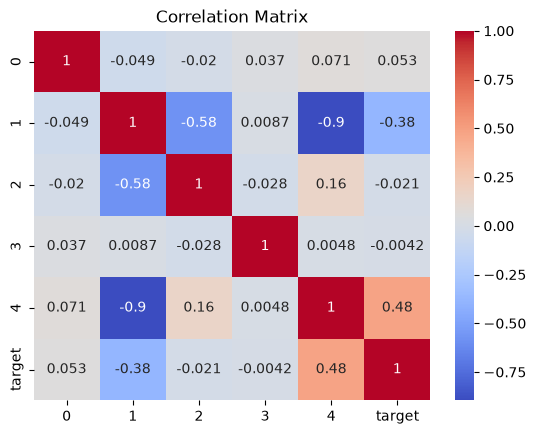

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_curve, precision_recall_curve, classification_report
X, y = make_classification(
    n_samples=1_000,
    n_features=5,
    n_informative=2,
    n_redundant=1,
    n_classes=2,
    weights=[0.1, 0.9],
    random_state=42
)

sns.heatmap(
    data=pd.concat([pd.DataFrame(X), pd.Series(y, name="target")], axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.55      0.67        20
           1       0.95      0.99      0.97       180

    accuracy                           0.94       200
   macro avg       0.90      0.77      0.82       200
weighted avg       0.94      0.94      0.94       200



array([       inf, 0.99998733, 0.98702754, 0.98700916, 0.98642425,
       0.98629802, 0.9721281 , 0.9719863 , 0.96177737, 0.9610328 ,
       0.93943565, 0.93638885, 0.84354018, 0.82249776, 0.78639756,
       0.76276637, 0.56592145, 0.34655368, 0.34277072, 0.11899152,
       0.1166544 , 0.08632467])

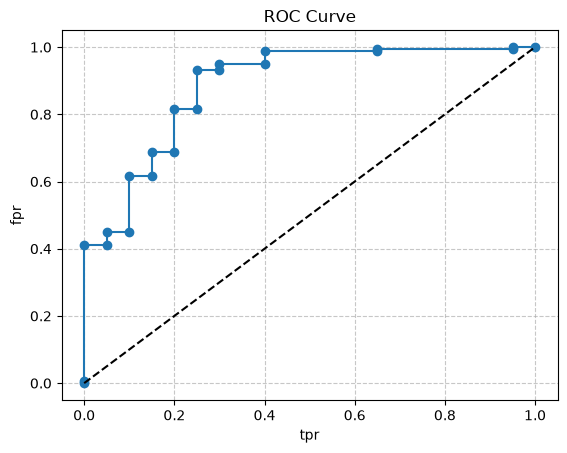

In [64]:
fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(X_test)[:, 1])

_, ax = plt.subplots()

ax.plot(fpr, tpr, marker="o")
ax.plot([0, 1], [0, 1], linestyle="--", color="black")

ax.set(
    title="ROC Curve",
    ylabel="fpr",
    xlabel="tpr"
)
plt.grid(True, linestyle="--", alpha=0.7)
thresholds

In [65]:
y_pred_new = (clf.predict_proba(X_test)[:, 1] > 0.86).astype(int)

print(classification_report(y_test, y_pred_new))

              precision    recall  f1-score   support

           0       0.52      0.75      0.61        20
           1       0.97      0.92      0.95       180

    accuracy                           0.91       200
   macro avg       0.74      0.84      0.78       200
weighted avg       0.93      0.91      0.91       200



In [66]:
from sklearn.metrics import accuracy_score
scores = []
thresholds = []
threshold = 1
while threshold >=0:
    y_pred = clf.predict_proba(X_test)[:, 1] > threshold
    f1 = f1_score(y_test, y_pred)
    print(f"Threshold: {threshold}, F1-Score: {f1}")
    thresholds.append(threshold)
    scores.append(f1)

    threshold -= 0.02

Threshold: 1, F1-Score: 0.0
Threshold: 0.98, F1-Score: 0.6468401486988847
Threshold: 0.96, F1-Score: 0.8051948051948052
Threshold: 0.94, F1-Score: 0.8780487804878049
Threshold: 0.9199999999999999, F1-Score: 0.9053254437869822
Threshold: 0.8999999999999999, F1-Score: 0.9149560117302052
Threshold: 0.8799999999999999, F1-Score: 0.927536231884058
Threshold: 0.8599999999999999, F1-Score: 0.9458689458689459
Threshold: 0.8399999999999999, F1-Score: 0.9518413597733711
Threshold: 0.8199999999999998, F1-Score: 0.9491525423728814
Threshold: 0.7999999999999998, F1-Score: 0.9550561797752809
Threshold: 0.7799999999999998, F1-Score: 0.957983193277311
Threshold: 0.7599999999999998, F1-Score: 0.9526462395543176
Threshold: 0.7399999999999998, F1-Score: 0.9555555555555556
Threshold: 0.7199999999999998, F1-Score: 0.9555555555555556
Threshold: 0.6999999999999997, F1-Score: 0.9584487534626038
Threshold: 0.6799999999999997, F1-Score: 0.9584487534626038
Threshold: 0.6599999999999997, F1-Score: 0.9670329670329

[Text(0.5, 1.0, 'F1-Score vs Threshold'),
 Text(0, 0.5, 'F1-Score'),
 Text(0.5, 0, 'Threshold')]

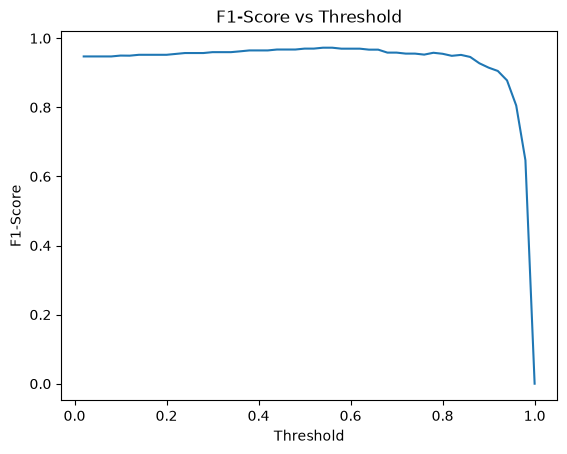

In [67]:
_, ax = plt.subplots()
ax.plot(thresholds, scores)
ax.set(
    title="F1-Score vs Threshold",
    ylabel="F1-Score",
    xlabel="Threshold"
)

Text(0, 0.5, 'Precision')

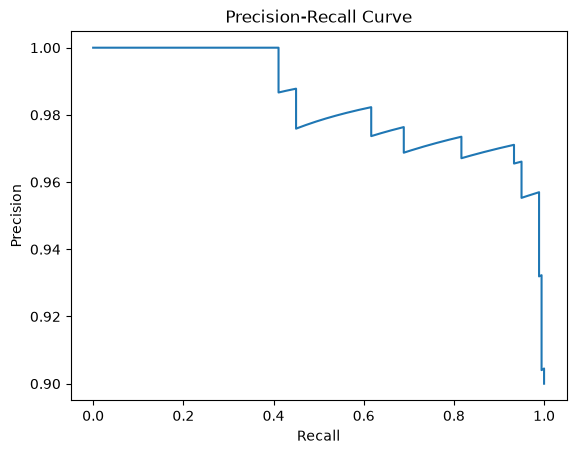

In [68]:
# plot precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, clf.predict_proba(X_test)[:,1])

_, ax = plt.subplots(1, 1)
ax.plot(recall, precision)
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')

In [69]:
thresholds

array([0.08632467, 0.1166544 , 0.11899152, 0.12512783, 0.21414175,
       0.22836942, 0.28178772, 0.34269276, 0.34277072, 0.34655368,
       0.3605389 , 0.42955844, 0.48877988, 0.52901169, 0.56592145,
       0.62211405, 0.66456874, 0.67401441, 0.67857353, 0.71068709,
       0.75500448, 0.76276637, 0.76685337, 0.78639756, 0.80029558,
       0.80960429, 0.82249776, 0.84354018, 0.8487567 , 0.86123359,
       0.86563228, 0.87006569, 0.8734126 , 0.87833878, 0.87856955,
       0.88173738, 0.88634974, 0.89853339, 0.89889941, 0.90293709,
       0.91438265, 0.91812423, 0.92234566, 0.92371494, 0.92474367,
       0.93206245, 0.93294157, 0.93518914, 0.93638885, 0.93943565,
       0.9396704 , 0.93969972, 0.94025728, 0.94039645, 0.94286587,
       0.94417831, 0.94457735, 0.9456669 , 0.94594154, 0.94891994,
       0.9489389 , 0.95028417, 0.95185906, 0.9523971 , 0.95290391,
       0.95452132, 0.95476777, 0.95544738, 0.95716764, 0.95756211,
       0.95787438, 0.95810638, 0.9610328 , 0.96177737, 0.96334

The main idea in using moving threshold is using ROC curve, Precision-Recall curve, and Grid search over the thresholds range to find the most suitable threshold for the given dataset. In indentifying the best threshold, we need to consider the cost of false positives and false negatives and the context of the problem we are trying to solve.

### 6. Using Tree-Based Models

Tree-based models are more suitable for imbalanced data sets. They are able to handle the imbalance by creating a tree structure that is more balanced. The tree structure is created by recursively splitting the data into smaller subsets until each subset has roughly the same number of samples. But the problem is they are very overfitting prone. So we need to use regularization techniques to avoid overfitting. Some algorithms to use are:
- Decision Trees
- Random Forests
- Gradient Boosed Trees

> **Note:** Gradient Boosted Trees works effectively but they are very sensitive to noise.

### 7.Using Anomaly Detection Algorithms

We can use the anomaly detection algorithms to handle imbalanced data. In anomaly detection algorithms we train the model on the normal data and then use the model on the data so if the data is normal we get 0 and if the data is anomaly so we got 1, We can say we train the model to identify the normal data so we can use it to detect anomalies.

In our context we can use the majority class as normal data and the minority class as anomaly so in this way we can build a classification tree to identify the class for the inputs that they are majority or not.